In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [32]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]

        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self.predict_one(x) for x in X]
        return np.array(y_pred)


In [24]:
knn_classes = [0, 0, 1, 1, 0, 0, 3, 3, 5]

np.argmax(np.bincount(knn_classes))

np.int64(0)

In [21]:
distances = [5.5, 2.4, 4.3, 1.6, 0.7]

np.argsort(distances)[:3]

array([4, 3, 1])

In [35]:
# Data 
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

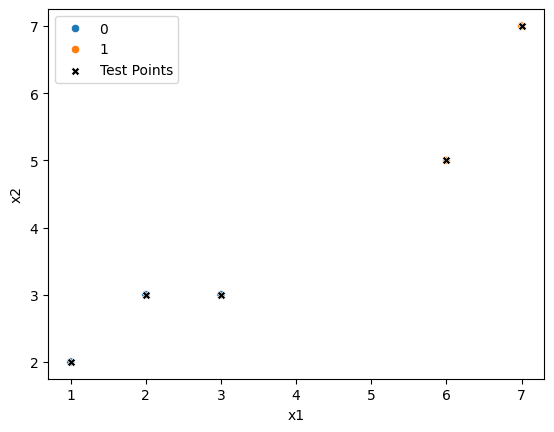

In [12]:
# Visualization
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)


In [4]:
X_train_df

,x1,x2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1
